# Prediction error growth vs forecast horizon

This notebook plots model error growth against GNSS SP3 precise-orbit positions as the forecast horizon increases.

In [31]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/Gavr101/space_modeling.git'


def run(cmd):
    print('>>', ' '.join(cmd))
    subprocess.check_call(cmd)


def find_project_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'dynamics').is_dir() and (candidate / 'visualization').is_dir():
            return candidate
    raise RuntimeError(f'Cannot find project root from {start}')


if IN_COLAB:
    PROJECT_ROOT = Path('/content/space_modeling')
    if not PROJECT_ROOT.exists():
        run(['git', 'clone', REPO_URL, str(PROJECT_ROOT)])
    os.chdir(PROJECT_ROOT)

    run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
    run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'])
    run([sys.executable, '-m', 'pip', 'install', '-e', '.'])
    # Optional: NRLMSISE-00 improves drag density modeling when available.
    try:
        run([sys.executable, '-m', 'pip', 'install', 'nrlmsise00'])
    except Exception as exc:
        print('Optional dependency nrlmsise00 was not installed:', exc)
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Working dir:', Path.cwd())


Working dir: C:\Users\Gavriil\VS_projects\space_modeling


## Precise-orbit reference data

`VELOCITY_REFERENCE_SOURCES` is shared with the propagation demo and contains only products with native velocity records: Swarm SP3, CASSIOPE/Swarm-E SP3, and Sentinel-1 POEORB EOF. GNSS CODE MGEX is kept separately as optional position-only data because this product has no SP3 velocity records.


In [32]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'dynamics').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dynamics.eof import eof_state_samples, read_sentinel_eof
from dynamics.propagator import PropagationConfig, SpacecraftProperties, propagate_orbit
from dynamics.sp3 import download_sp3, read_sp3, sp3_state_samples


In [33]:
VELOCITY_REFERENCE_SOURCES = {
    'Sentinel-1A': {
        'format': 'sentinel_eof',
        'url': 'https://s1-orbits.s3.us-west-2.amazonaws.com/AUX_POEORB/S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF',
        'path': PROJECT_ROOT / 'data' / 'eof' / 'S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF',
        'requires_velocity': True,
        'velocity_source': 'sentinel_eof_osv',
        'spacecraft': SpacecraftProperties(mass=2185.0, cd=2.2, cr=1.3, reference_area=10.3),
    },
    'Sentinel-1B': {
        'format': 'sentinel_eof',
        'url': 'https://s1-orbits.s3.us-west-2.amazonaws.com/AUX_POEORB/S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF',
        'path': PROJECT_ROOT / 'data' / 'eof' / 'S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF',
        'requires_velocity': True,
        'velocity_source': 'sentinel_eof_osv',
        'spacecraft': SpacecraftProperties(mass=2185.0, cd=2.2, cr=1.3, reference_area=10.3),
    },
    'CASSIOPE / Swarm-E': {
        'format': 'sp3',
        'satellite_id': 'L63',
        'url': 'https://epop-data.phys.ucalgary.ca/2017/02/01/CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip',
        'path': PROJECT_ROOT / 'data' / 'sp3' / 'CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip',
        'requires_velocity': True,
        'velocity_source': 'sp3_velocity_records',
        'spacecraft': SpacecraftProperties(mass=500.0, cd=2.2, cr=1.3, reference_area=2.2),
    },
    'Swarm B': {
        'format': 'sp3',
        'satellite_id': 'L48',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_B%2FSW_OPER_SP3BCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': PROJECT_ROOT / 'data' / 'sp3' / 'SW_OPER_SP3BCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'requires_velocity': True,
        'velocity_source': 'sp3_velocity_records',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
    'Swarm C': {
        'format': 'sp3',
        'satellite_id': 'L49',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_C%2FSW_OPER_SP3CCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': PROJECT_ROOT / 'data' / 'sp3' / 'SW_OPER_SP3CCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'requires_velocity': True,
        'velocity_source': 'sp3_velocity_records',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
    'Swarm A': {
        'format': 'sp3',
        'satellite_id': 'L47',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_A%2FSW_OPER_SP3ACOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': PROJECT_ROOT / 'data' / 'sp3' / 'SW_OPER_SP3ACOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'requires_velocity': True,
        'velocity_source': 'sp3_velocity_records',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
}

POSITION_ONLY_GNSS_SOURCES = {
    'QZSS J04': {'format': 'sp3', 'satellite_id': 'J04', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'BeiDou C09': {'format': 'sp3', 'satellite_id': 'C09', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'QZSS J03': {'format': 'sp3', 'satellite_id': 'J03', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'Galileo E14': {'format': 'sp3', 'satellite_id': 'E14', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'BeiDou C11': {'format': 'sp3', 'satellite_id': 'C11', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'GPS G21': {'format': 'sp3', 'satellite_id': 'G21', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'GLONASS R20': {'format': 'sp3', 'satellite_id': 'R20', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
}

EARTH_RADIUS_M = 6_378_137.0
DURATION_HOURS = 12
STEP_SECONDS = 60.0


In [34]:
def download_reference_file(source):
    return download_sp3(source['url'], source['path'])


def reference_has_native_velocity(source, path):
    if source['format'] == 'sp3':
        orbit = read_sp3(path)
        return source['satellite_id'] in getattr(orbit, 'velocities_m_s', {})
    if source['format'] == 'sentinel_eof':
        orbit = read_sentinel_eof(path)
        return orbit.velocities_m_s.shape[0] >= 2
    raise ValueError(f'Unsupported reference format: {source["format"]}')


def load_reference_orbit(source, duration_hours=DURATION_HOURS, step_seconds=STEP_SECONDS):
    path = download_reference_file(source)
    has_velocity = reference_has_native_velocity(source, path)
    if source.get('requires_velocity', False) and not has_velocity:
        raise ValueError(f'{path.name} does not contain native velocity records required for this source.')

    if source['format'] == 'sp3':
        epochs, states = sp3_state_samples(
            path,
            source['satellite_id'],
            duration_hours=duration_hours,
            step_seconds=step_seconds,
        )
    elif source['format'] == 'sentinel_eof':
        epochs, states = eof_state_samples(
            path,
            duration_hours=duration_hours,
            step_seconds=step_seconds,
        )
    else:
        raise ValueError(f'Unsupported reference format: {source["format"]}')
    return path, epochs, states, has_velocity


def median_altitude_km(states):
    return float(np.median(np.linalg.norm(states[:, :3], axis=1) - EARTH_RADIUS_M) / 1000.0)


def model_from_initial_state(
    initial_state,
    start_epoch,
    duration_hours=DURATION_HOURS,
    step_seconds=STEP_SECONDS,
    spacecraft_prop=SpacecraftProperties(500.0, 2.2, 1.3, 2.2),
):
    cfg = PropagationConfig(
        initial_state=initial_state,
        epoch_seconds=float(start_epoch.unix),
        duration_seconds=duration_hours * 3600.0,
        step_seconds=step_seconds,
        integrator='DOP853',
        spacecraft=spacecraft_prop,
    )
    # Keep drag on the reproducible fallback atmosphere in Colab-like environments.
    cfg.environment.force_models.nrlmsise00_atmosphere = False
    _, model_states = propagate_orbit(cfg)
    return model_states



def compute_prediction_error(name, source, horizon_h=12, step_s=60.0):
    ref_path, epochs_ref, states_ref, has_velocity = load_reference_orbit(
        source,
        duration_hours=horizon_h,
        step_seconds=step_s,
    )
    actual_horizon_h = (states_ref.shape[0] - 1) * step_s / 3600.0
    states_model = model_from_initial_state(
        states_ref[0],
        epochs_ref[0],
        duration_hours=actual_horizon_h,
        step_seconds=step_s,
        spacecraft_prop=source['spacecraft'],
    )

    r_ref = states_ref[:, :3]
    v_ref = states_ref[:, 3:]
    r_model = states_model[:, :3]
    v_model = states_model[:, 3:]

    h_ref = np.linalg.norm(r_ref, axis=1) - EARTH_RADIUS_M
    h_model = np.linalg.norm(r_model, axis=1) - EARTH_RADIUS_M

    return {
        'name': name,
        'source': source,
        'path': ref_path,
        'has_velocity': has_velocity,
        'median_altitude_km': median_altitude_km(states_ref),
        't_hours': np.arange(states_ref.shape[0], dtype=float) * step_s / 3600.0,
        'delta_r_km': np.linalg.norm(r_model - r_ref, axis=1) / 1000.0,
        'delta_h_km': np.abs(h_model - h_ref) / 1000.0,
        'delta_v_km_s': np.linalg.norm(v_model - v_ref, axis=1) / 1000.0,
    }


In [35]:
sat_name = 'Sentinel-1A'
forecast_horizon_h = 12
step_seconds = 60.0

source = VELOCITY_REFERENCE_SOURCES[sat_name]
single_error = compute_prediction_error(
    sat_name,
    source,
    horizon_h=forecast_horizon_h,
    step_s=step_seconds,
)

t_hours = single_error['t_hours']
delta_r_km = single_error['delta_r_km']
delta_h_km = single_error['delta_h_km']
delta_v_km_s = single_error['delta_v_km_s']

print(f'Satellite: {sat_name}')
print(f'Reference source: {single_error["path"].name}')
print(f'Reference format: {source["format"]}')
print(f'Median altitude: {single_error["median_altitude_km"]:.1f} km')
print(f'Native velocity records: {single_error["has_velocity"]}')
print(f'Max position residual: {delta_r_km.max():.2f} km')
print(f'Max altitude residual: {delta_h_km.max():.2f} km')
print(f'Max speed residual: {delta_v_km_s.max():.4f} km/s')


100%|██████████| 721/721 [00:10<00:00, 68.59it/s] 

Satellite: Sentinel-1A
Reference source: S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF
Reference format: sentinel_eof
Median altitude: 698.4 km
Native velocity records: True
Max position residual: 2.48 km
Max altitude residual: 0.26 km
Max speed residual: 0.0025 km/s


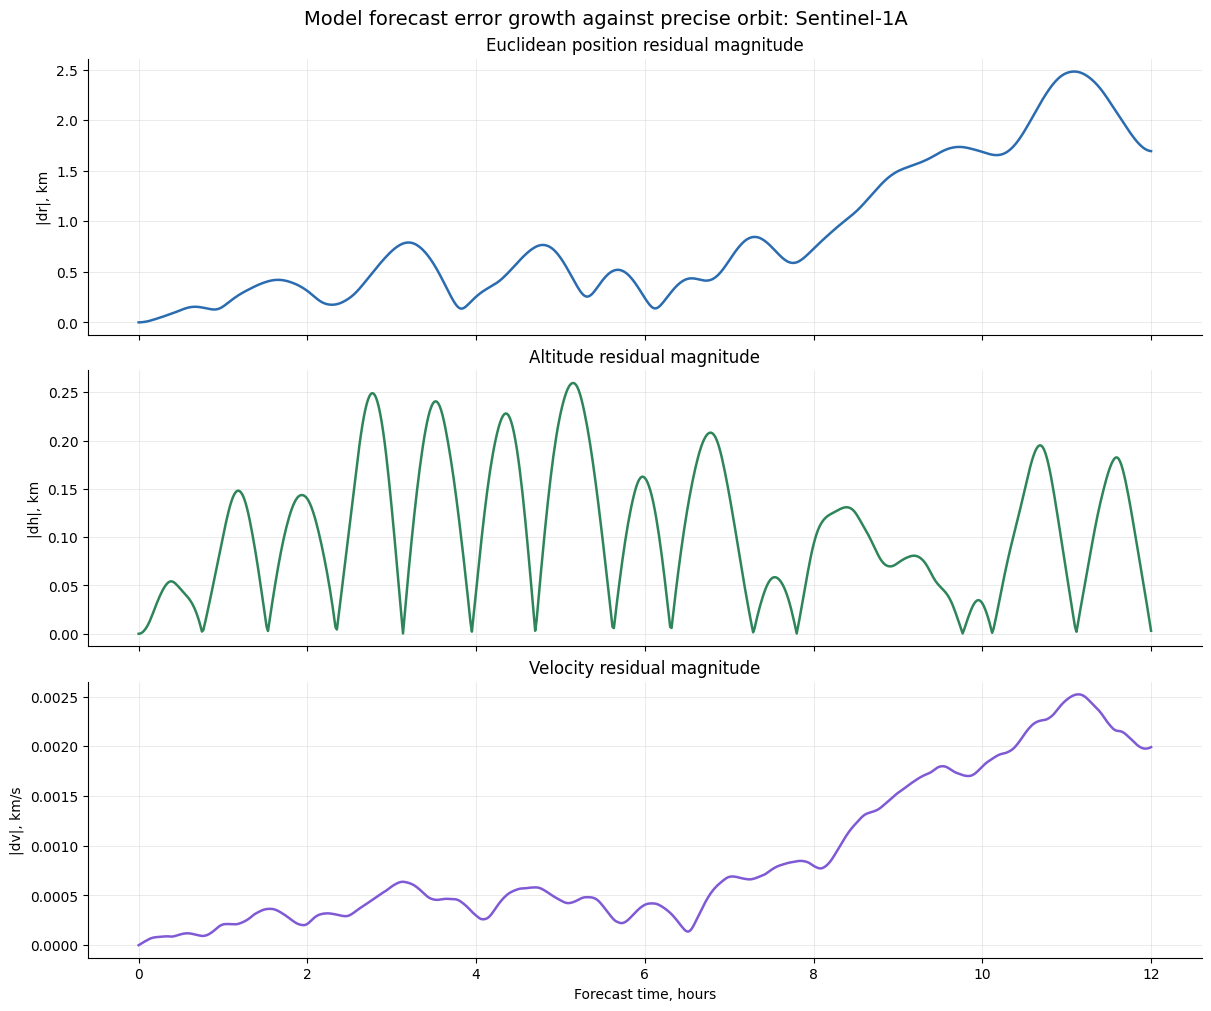

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, constrained_layout=True)

plot_style = {
    'position': {'color': '#2b6cb0', 'lw': 1.8},
    'altitude': {'color': '#2f855a', 'lw': 1.8},
    'velocity': {'color': '#805ad5', 'lw': 1.8},
}

axes[0].plot(t_hours, delta_r_km, **plot_style['position'])
axes[0].set_ylabel('|dr|, km')
axes[0].set_title('Euclidean position residual magnitude')

axes[1].plot(t_hours, delta_h_km, **plot_style['altitude'])
axes[1].set_ylabel('|dh|, km')
axes[1].set_title('Altitude residual magnitude')

axes[2].plot(t_hours, delta_v_km_s, **plot_style['velocity'])
axes[2].set_ylabel('|dv|, km/s')
axes[2].set_xlabel('Forecast time, hours')
axes[2].set_title('Velocity residual magnitude')

for ax in axes:
    ax.grid(True, alpha=0.25, linewidth=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'Model forecast error growth against precise orbit: {sat_name}', fontsize=14)
plt.show()


100%|██████████| 721/721 [00:05<00:00, 133.69it/s]


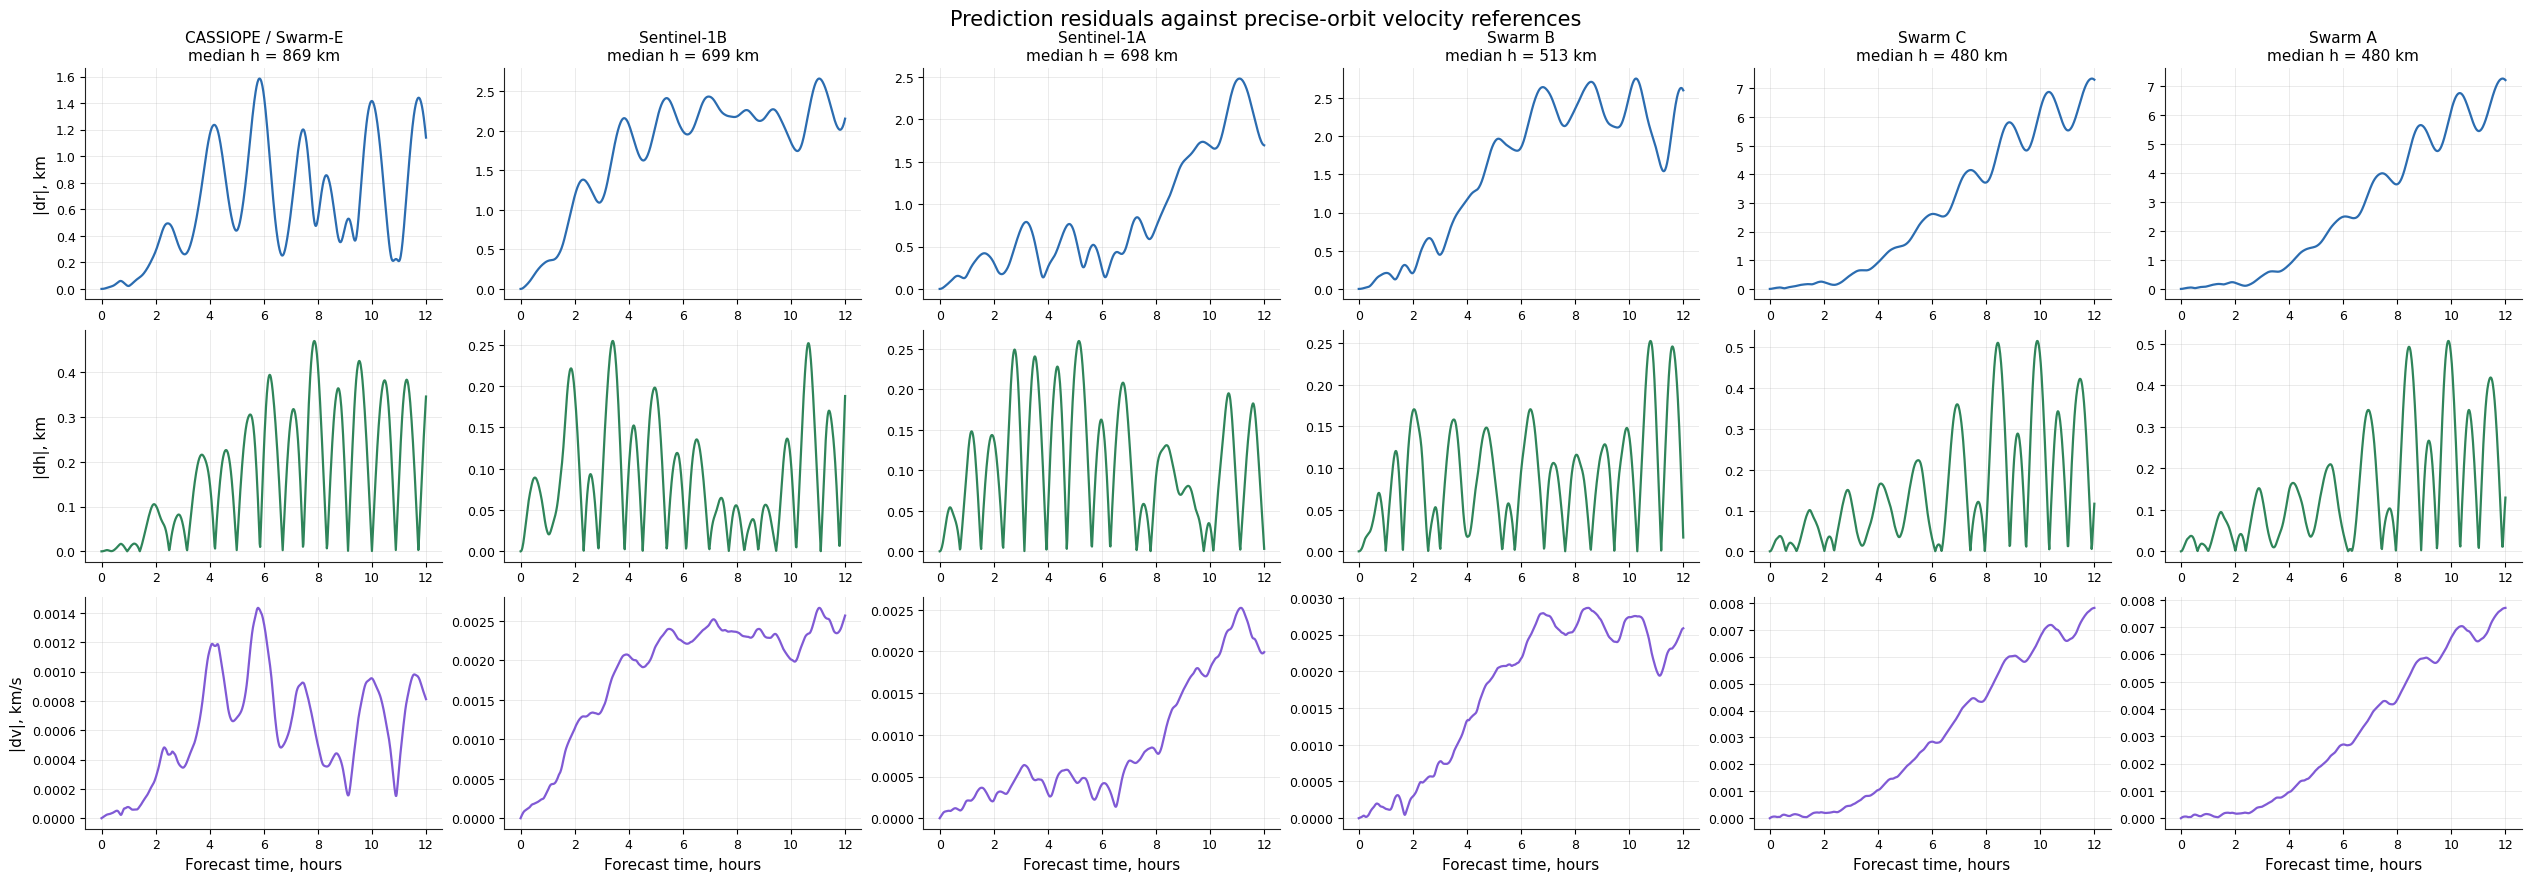

CASSIOPE / Swarm-E: native velocity = True, median h = 869.2 km, max |dr| = 1.58 km, max |dh| = 0.47 km, max |dv| = 0.0014 km/s
Sentinel-1B: native velocity = True, median h = 699.3 km, max |dr| = 2.66 km, max |dh| = 0.25 km, max |dv| = 0.0027 km/s
Sentinel-1A: native velocity = True, median h = 698.4 km, max |dr| = 2.48 km, max |dh| = 0.26 km, max |dv| = 0.0025 km/s
Swarm B: native velocity = True, median h = 513.4 km, max |dr| = 2.75 km, max |dh| = 0.25 km, max |dv| = 0.0029 km/s
Swarm C: native velocity = True, median h = 480.2 km, max |dr| = 7.34 km, max |dh| = 0.52 km, max |dv| = 0.0078 km/s
Swarm A: native velocity = True, median h = 480.2 km, max |dr| = 7.24 km, max |dh| = 0.51 km, max |dv| = 0.0077 km/s


In [37]:
all_errors = [
    compute_prediction_error(
        sat_name,
        source,
        horizon_h=forecast_horizon_h,
        step_s=step_seconds,
    )
    for sat_name, source in VELOCITY_REFERENCE_SOURCES.items()
]
all_errors.sort(key=lambda item: item['median_altitude_km'], reverse=True)

if not all(item['has_velocity'] for item in all_errors):
    missing = [item['name'] for item in all_errors if not item['has_velocity']]
    raise ValueError(f'Sources without native velocity records: {missing}')

n_sats = len(all_errors)
metric_rows = [
    ('delta_r_km', '|dr|, km', '#2b6cb0'),
    ('delta_h_km', '|dh|, km', '#2f855a'),
    ('delta_v_km_s', '|dv|, km/s', '#805ad5'),
]

with plt.rc_context({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#222222',
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.size': 10,
}):
    fig, axes = plt.subplots(
        len(metric_rows),
        n_sats,
        figsize=(4.2 * n_sats, 8.5),
        sharex=False,
        constrained_layout=True,
    )

    if n_sats == 1:
        axes = axes.reshape(len(metric_rows), 1)

    for col, item in enumerate(all_errors):
        for row, (metric_key, ylabel, color) in enumerate(metric_rows):
            ax = axes[row, col]
            y = np.maximum(item[metric_key], np.finfo(float).tiny)
            ax.plot(item['t_hours'], y, color=color, lw=1.6)
            ax.grid(True, alpha=0.25, linewidth=0.7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if col == 0:
                ax.set_ylabel(ylabel)
            if row == len(metric_rows) - 1:
                ax.set_xlabel('Forecast time, hours')
            if row == 0:
                ax.set_title(f'{item["name"]}\nmedian h = {item["median_altitude_km"]:.0f} km')

    fig.suptitle(
        'Prediction residuals against precise-orbit velocity references',
        fontsize=15,
        y=1.02,
    )
    plt.show()

for item in all_errors:
    print(
        f'{item["name"]}: native velocity = {item["has_velocity"]}, '
        f'median h = {item["median_altitude_km"]:.1f} km, '
        f'max |dr| = {item["delta_r_km"].max():.2f} km, '
        f'max |dh| = {item["delta_h_km"].max():.2f} km, '
        f'max |dv| = {item["delta_v_km_s"].max():.4f} km/s'
    )
